# World Cup 2026 close-up

**Review notebook** for the World Cup part of the sponsorship (ADR-0038). The headline estimate is the total sponsorship effect in `10_total_sponsorship_effect.ipynb`; this notebook zooms in on the tournament in two complementary views:

- **View A, within the total effect:** how far Lenovo sat above its *no-sponsorship* twin during the tournament and after the final (`sponsorship_total_effect_v1`).
- **View B, incremental:** whether the tournament added salience *on top of* Lenovo's pre-tournament trajectory, which already included the sponsorship (`world_cup_impact_v1`, pre-registered: ADR-0019, ADR-0029).

> **Status: INTERIM.** The pre-registered evaluation window closes on 18 October 2026 and several acceptance gates of View B are still open (section 5.2). Nothing here is an accepted World Cup effect.

> **Protocol amendment (ADR-0040).** Before the window closed, the owner replaced the outcome: the pre-registered "Brand Index" is now the brand-level index (brand share of attention against rivals, informed by the GWI survey; `05_brand_index.ipynb`), and the donor brands enter on the same share-of-search basis. Estimators, estimand, donors, gates and thresholds are unchanged. The change was made after interim tournament results on the old index had been seen, which this notebook states openly.

*How to use:* run all cells. Read-only unless `RUN_REBUILD = True`. Every number in the narrative is computed from the current outputs.

In [1]:
# Setup: read-only by default (AGENTS.md). Nothing below rewrites data unless RUN_REBUILD is True.
RUN_REBUILD = False   # set True only to regenerate the production outputs this notebook reads

import json, os, subprocess, sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "srmp").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from srmp.review import stamp_sources

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.figsize": (10, 4.2), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

def md(text):
    display(Markdown(text))

def fmt(value, digits=2, signed=False):
    return f"{value:+.{digits}f}" if signed else f"{value:.{digits}f}"

if RUN_REBUILD:  # explicit opt-in: re-runs the readiness check and the estimator (about a minute)
    subprocess.run([sys.executable, "-m", "srmp.experiments.world_cup_impact_v1"], check=True)

W = "data/curated/experimental/world_cup_impact_v1/"
T = "data/curated/experimental/sponsorship_total_effect_v1/"
SOURCES = [
    T + "total_effect_weekly.parquet", T + "estimate_manifest.json",
    "config/experiments/world_cup_impact_v1.yaml",
    W + "readiness_manifest.json", W + "estimate_manifest.json", W + "estimates.parquet",
    W + "weekly_paths.parquet", W + "donor_placebos.parquet", W + "confounder_diagnostics.json",
    "data/staged/blinkfire/blinkfire_exposure_weekly.parquet",
    "data/staged/fifa_calendar/official_fifa_calendar.parquet",
]
stamp_sources(SOURCES)

REVIEW_SOURCES={"data/curated/experimental/sponsorship_total_effect_v1/total_effect_weekly.parquet": "6cbb71b4f5557eea51e122e4b19bf3efb645686a8dad9986d0366f4043ae26fa", "data/curated/experimental/sponsorship_total_effect_v1/estimate_manifest.json": "0a69c77b109e24be645d9d52574d5d11ba3c44c3ffc50b8d44da15db6ab9eb4c", "config/experiments/world_cup_impact_v1.yaml": "685f3a493fed266480be11c48c8a42b8d64378e320fc876cf2ac70a65c1ed803", "data/curated/experimental/world_cup_impact_v1/readiness_manifest.json": "a35fb19bd38ceab0683c0bb8b48e0deb097ee15b46b06b089ada2b306874d9cc", "data/curated/experimental/world_cup_impact_v1/estimate_manifest.json": "4a63e3b34b22a27ca06de50404b364dd4ad96e6d28600744e2738656ffeb4d80", "data/curated/experimental/world_cup_impact_v1/estimates.parquet": "6f8e65130c564bc142553db55b50e0c24fa86123a0b825bec057e7df62ed2085", "data/curated/experimental/world_cup_impact_v1/weekly_paths.parquet": "b2af5bfc2c61bb386d40d0e3f7cfecfc1ec7ad07820f840dfd29344a9c18babe", "data/curated/

,file,sha256,last_generated_utc,size_kb
0,data/curated/experimental/sponsorship_total_ef...,6cbb71b4f555,NaN,11.7
1,data/curated/experimental/sponsorship_total_ef...,0a69c77b109e,2026-10-08T08:23:28.450960+00:00,4.6
2,config/experiments/world_cup_impact_v1.yaml,685f3a493fed,NaN,5.5
3,data/curated/experimental/world_cup_impact_v1/...,a35fb19bd38c,2026-10-08T08:35:03.356268+00:00,5.1
4,data/curated/experimental/world_cup_impact_v1/...,4a63e3b34b22,2026-10-08T08:35:34.951701+00:00,6.1
5,data/curated/experimental/world_cup_impact_v1/...,6f8e65130c56,NaN,7.5
6,data/curated/experimental/world_cup_impact_v1/...,b2af5bfc2c61,NaN,32.0
7,data/curated/experimental/world_cup_impact_v1/...,74ad7303b634,NaN,5.2
8,data/curated/experimental/world_cup_impact_v1/...,87da023cf53c,NaN,1.9
9,data/staged/blinkfire/blinkfire_exposure_weekl...,0b57226cf8d8,NaN,16.2


## 1. Question and purpose

**Questions.** During the Men's World Cup (11 June – 19 July 2026), where Lenovo was an official FIFA partner, (A) how far above its no-sponsorship path was Lenovo's brand salience, and (B) did the tournament add salience *on top of* Lenovo's pre-tournament trajectory, with any lift persisting after the final?

**Why it matters.** The World Cup is the sponsorship's largest exposure event. The evaluation was pre-registered in July 2026 (estimand, methods, donors, thresholds) so that the answer cannot be shaped after seeing the outcome.

**Objective supported.** Confirming or rejecting a sponsorship-attributable brand uplift with the cleanest available design.

## 2. Evidence and inputs

| Input | Role | Source | Label |
|---|---|---|---|
| Lenovo Brand Index | Outcome: brand share of attention, 100 = pre-announcement average | Google Trends share of search + GWI (to 2026Q1) | **constructed** |
| Donor brands (registry `base`, 11, plus Huawei for sensitivity) | Comparison units, each as its share of search against the other base rivals | Google Trends common-anchor panels | **observed** → **constructed** (rescaled, share) |
| FIFA-family exposure | Weights the primary estimand | Blinkfire client exports through 20 Jul 2026 | **observed** (digital/social only) |
| Official match calendar | Tournament and final dates | FIFA public API snapshot | **observed** |
| Activation start | Treatment start | Client (not yet supplied) | **assumed** provisionally = tournament-start week (8 Jun 2026) |
| Lenovo event calendar | Event-week exclusion robustness | Lenovo press kits | **observed** |
| Media value | Broadcast-inclusive weighting | Client export (ends Apr 2026) | not yet available for the window |

In [2]:
readiness = json.loads(Path(W + "readiness_manifest.json").read_text())
rows = [{"Source": r["source"], "Status": r["status"], "Covers through": r.get("coverage_end"),
         "Required through": r.get("required_coverage_through"), "Required for estimation": r["required_for_estimation"]}
        for r in readiness["source_readiness"]]
display(pd.DataFrame(rows))
md(f"**Table 1.** Data readiness. Missing milestone dates: {', '.join(readiness['missing_milestone_dates']) or 'none'}. "
   f"Sources still waiting: {', '.join(readiness['required_sources_waiting']) or 'none'}.")

,Source,Status,Covers through,Required through,Required for estimation
0,brand_index,available_coverage_incomplete,2026-09-28,2026-10-18,True
1,jointly_scaled_donor_trends,available_pending_coverage_check,2026-09-27,NaN,True
2,world_cup_exposure,available_coverage_incomplete,2026-07-20,2026-10-18,True
3,world_cup_event_calendar,available_pending_coverage_check,NaN,NaN,True
4,product_launch_controls,available_pending_coverage_check,NaN,NaN,True
5,broadcast_grp,waiting_for_path,NaN,NaN,False
6,post_world_cup_survey,waiting_for_path,NaN,NaN,False


**Table 1.** Data readiness. Missing milestone dates: activation_start. Sources still waiting: brand_index, world_cup_exposure.

## 3. Method and formulas

The engine compares Lenovo with a synthetic Lenovo built from rival brands, using only data before the treatment week $T$ to fit the comparison (all series standardised with pre-$T$ moments). Four estimators are run (`srmp/counterfactual/scm.py`):

- **Augmented SCM (primary, pre-registered).** Simplex weights $\hat w$ (non-negative, summing to one) plus a ridge correction $\gamma = \hat w + (X_0X_0' + \lambda I)^{-1}X_0(y_{pre} - X_0'\hat w)$. *In words:* start from the best convex mix of rivals, then allow a small regularised extrapolation to fix remaining pre-period mismatch. $\lambda$ = multiplier × training weeks, chosen on an inner pre-period split.
- **Simplex SCM** and **synthetic difference-in-differences** (robustness, pre-registered).
- **Generalized SCM factor model** (robustness added *after* partial outcomes were seen, ADR-0029; never primary): Lenovo-specific loadings on common factors extracted from donors, so a stronger reaction to category-wide shocks is modelled.

**Primary estimand (pre-registered).** Exposure-weighted mean gap over the registered window $[T, \text{18 Oct 2026}]$:

$$\Delta = \frac{\sum_t a_t\, \text{gap}_t}{\sum_t a_t},\qquad a_t = \text{FIFA-family impressions adstock},\ a_t = i_t + 0.8\,a_{t-1}.$$

*In words:* the average Lenovo-minus-twin gap, giving more weight to weeks with more (and recently accumulated) FIFA exposure. Weeks without observed Blinkfire data get **no** weight (unobserved is not zero).

**Secondary estimands.** Mean gap during the tournament, mean gap after the final (persistence), peak 4-week mean, and the primary with Lenovo event weeks excluded.

**Inference.** Each donor is treated as pseudo-sponsored; $p = (1 + \#\{R_j \ge R_{Lenovo}\})/(1+J)$ on the post/pre RMSPE ratio $R$. An interval is the estimate ± the 90th percentile of absolute placebo pseudo-effects.

**Acceptance gates.** A result is handed to valuation only if *all* hold: approved activation date; Brand Index and exposure cover the window; outcome and donor Trends pulls within 7 days of each other; ≥104 pre weeks; ≥9 donors; ≥13 post-tournament weeks; placebo $p \le 0.10$. The last two weeks of every Trends pull are excluded as provisional.

## 4. Calculation path

| Step | Code | Configuration | Output |
|---|---|---|---|
| Stage the official calendar | `srmp/ingest/fifa_calendar.py` | `config/fifa_calendar.yaml` | `data/staged/fifa_calendar/` |
| Ingest Blinkfire (incl. World Cup export) | `srmp/ingest/blinkfire.py`, `srmp/exposure/aggregate.py` | — | `data/staged/blinkfire/` |
| Readiness check | `srmp/experiments/world_cup_impact_v1.py` (`build_world_cup_skeleton`) | `config/experiments/world_cup_impact_v1.yaml` | `readiness_manifest.json` |
| Estimation, placebos, gates, diagnostics | `srmp/experiments/world_cup_impact_v1_estimator.py` (`estimate_world_cup_impact`) | same | `estimate_manifest.json`, `estimates`, `weekly_paths`, `donor_placebos`, `confounder_diagnostics.json` |

## 5. Results

### 5.1 View A: the World Cup within the total sponsorship effect

Period,From,To,Weeks,Gap vs no-sponsorship twin (Index pts)
Sponsorship before the tournament,2024-10-21,2026-06-07,85,+6.97
Men's World Cup (tournament weeks),2026-06-08,2026-07-19,6,+7.14
After the final,2026-07-20,2026-09-14,9,+12.56
Whole sponsorship period (headline),2024-10-21,2026-09-14,100,+7.48


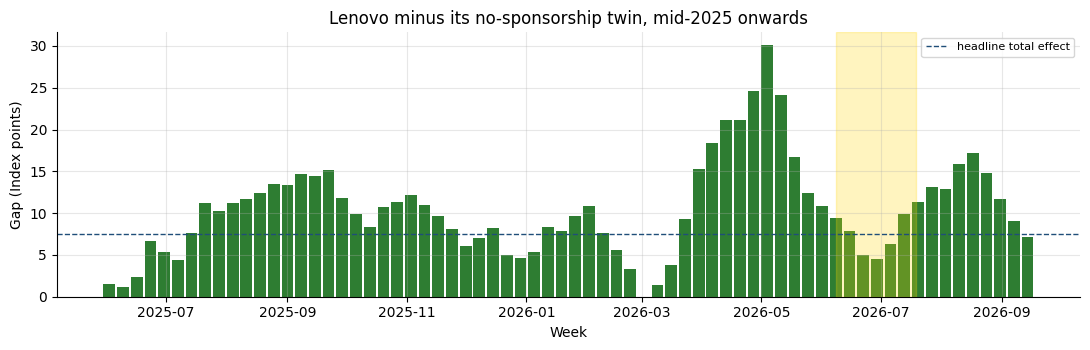

**Table A and Figure A.** Against the no-sponsorship twin, the tournament weeks average +7.14 points and the weeks after the final +12.56, compared with +6.97 earlier in the sponsorship and +7.48 overall. These are part of the headline estimate, not separate tests.

In [3]:
tw = pd.read_parquet(T + "total_effect_weekly.parquet"); tw["week"] = pd.to_datetime(tw["week"])
te = json.loads(Path(T + "estimate_manifest.json").read_text())["total_effect"]
def window(a, b):
    m = (tw["week"] >= pd.Timestamp(a)) & (tw["week"] <= pd.Timestamp(b))
    return int(m.sum()), float(tw.loc[m, "index_gap"].mean())
rows = [("Sponsorship before the tournament", te["first_post_week"], "2026-06-07"),
        ("Men's World Cup (tournament weeks)", "2026-06-08", "2026-07-19"),
        ("After the final", "2026-07-20", te["last_week"]),
        ("Whole sponsorship period (headline)", te["first_post_week"], te["last_week"])]
view_a = pd.DataFrame([{"Period": n, "From": a, "To": b, "Weeks": window(a, b)[0], "Gap vs no-sponsorship twin (Index pts)": window(a, b)[1]}
                       for n, a, b in rows])
display(view_a.style.format({"Gap vs no-sponsorship twin (Index pts)": "{:+.2f}"}).hide(axis="index"))
recent = tw[tw["week"] >= "2025-06-01"]
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.bar(recent["week"], recent["index_gap"], width=6, color=np.where(recent["index_gap"] >= 0, "#2e7d32", "#c62828"))
ax.axvspan(pd.Timestamp("2026-06-08"), pd.Timestamp("2026-07-19"), color="gold", alpha=0.25)
ax.axhline(te["lift_index_points"], color="#1f4e79", ls="--", lw=1, label="headline total effect")
ax.set_ylabel("Gap (Index points)"); ax.set_xlabel("Week"); ax.legend(fontsize=8)
ax.set_title("Lenovo minus its no-sponsorship twin, mid-2025 onwards")
plt.tight_layout(); plt.show()
md(f"**Table A and Figure A.** Against the no-sponsorship twin, the tournament weeks average {fmt(view_a.iloc[1, 4], signed=True)} points and the weeks after the "
   f"final {fmt(view_a.iloc[2, 4], signed=True)}, compared with {fmt(view_a.iloc[0, 4], signed=True)} earlier in the sponsorship and "
   f"{fmt(te['lift_index_points'], signed=True)} overall. These are part of the headline estimate, not separate tests.")

### 5.2 View B: incremental effect above the pre-tournament trajectory (acceptance gates)

In [4]:
est = json.loads(Path(W + "estimate_manifest.json").read_text())
gates = pd.DataFrame(est["gates"]).rename(columns={"gate": "Gate", "passed": "Passed", "detail": "Detail"})
display(gates)
md(f"**Table 2.** Status: **{est['status']}**. Treatment week {est['treatment_week']} ({est['treatment_week_status']}); "
   f"final week {est['final_week']}; window ends {est['window_end_week']}. "
   f"Data through: Brand Index {est['data_through']['brand_index']}, FIFA exposure {est['data_through']['fifa_exposure']}. "
   f"{int((~gates['Passed']).sum())} of {len(gates)} gates are open.")

,Gate,Passed,Detail
0,activation_start_approved,False,provisional treatment week 2026-06-08 (tournam...
1,brand_index_covers_window,False,"index through 2026-09-20, window ends 2026-10-18"
2,exposure_covers_window,False,Blinkfire through 2026-07-20
3,outcome_and_donor_vintages_aligned,True,pulls 0.0 days apart
4,minimum_pre_weeks,True,231 pre weeks
5,minimum_credible_donors,True,11 base donors
6,minimum_post_weeks_after_tournament,False,9 observed post-tournament weeks
7,placebo_p_value,False,p = 0.1667 over 11 donor placebos


**Table 2.** Status: **interim_estimate_gates_not_met**. Treatment week 2026-06-08 (provisional); final week 2026-07-13; window ends 2026-10-12. Data through: Brand Index 2026-09-20, FIFA exposure 2026-07-20. 5 of 8 gates are open.

### 5.3 View B: estimates by method

In [5]:
estimates = pd.read_parquet(W + "estimates.parquet")
labels = {"method": "Method", "role": "Role", "pre_rmspe_index_points": "Pre-period fit error",
          "holdout_rmspe_index_points": "26-week holdout error", "primary_exposure_weighted_gap": "Primary: exposure-weighted gap",
          "primary_event_weeks_excluded": "Primary, event weeks excluded", "all_post_mean_gap": "Mean gap, whole window",
          "tournament_mean_gap": "Mean gap, tournament", "peak_four_week_mean_gap": "Peak 4-week mean",
          "post_event_persistence_mean_gap": "Mean gap after the final"}
display(estimates.rename(columns=labels).style.format(precision=2).hide(axis="index"))
prim = est["primary"]
md(f"**Table 3.** All values in Brand Index points. Primary (ASCM) exposure-weighted gap: **{fmt(prim['primary_exposure_weighted_gap'], signed=True)}**; "
   f"tournament weeks {fmt(prim['tournament_mean_gap'], signed=True)}; after the final {fmt(prim['post_event_persistence_mean_gap'], signed=True)} "
   f"({est['panel']['persistence_weeks_observed']} of 13 required weeks observed). The ASCM 26-week holdout error "
   f"({fmt(prim['holdout_rmspe_index_points'])}) is {prim['holdout_rmspe_index_points'] / prim['pre_rmspe_index_points']:.1f}× its in-sample fit error "
   f"({fmt(prim['pre_rmspe_index_points'])}): the comparison predicts the run-up to the tournament poorly, which widens the real uncertainty.")

Method,Role,Pre-period fit error,26-week holdout error,Primary: exposure-weighted gap,"Primary, event weeks excluded","Mean gap, whole window","Mean gap, tournament",Peak 4-week mean,Mean gap after the final
augmented_scm,primary,3.63,9.79,0.58,0.58,2.67,-1.47,9.04,5.43
simplex_scm,robustness,4.80,11.35,2.89,2.89,4.99,2.20,9.24,6.86
synthetic_did,robustness,6.86,11.90,1.09,1.09,3.95,0.07,9.09,6.53
generalized_scm_factor,robustness_category_shock_added_after_partial_outcome_ADR_0029,4.49,11.83,0.98,0.98,4.24,-0.22,10.70,7.21
augmented_scm_with_sensitivity_donors,sensitivity,3.03,nan,1.60,1.60,2.54,-0.46,7.38,4.55


**Table 3.** All values in Brand Index points. Primary (ASCM) exposure-weighted gap: **+0.58**; tournament weeks -1.47; after the final +5.43 (9 of 13 required weeks observed). The ASCM 26-week holdout error (9.79) is 2.7× its in-sample fit error (3.63): the comparison predicts the run-up to the tournament poorly, which widens the real uncertainty.

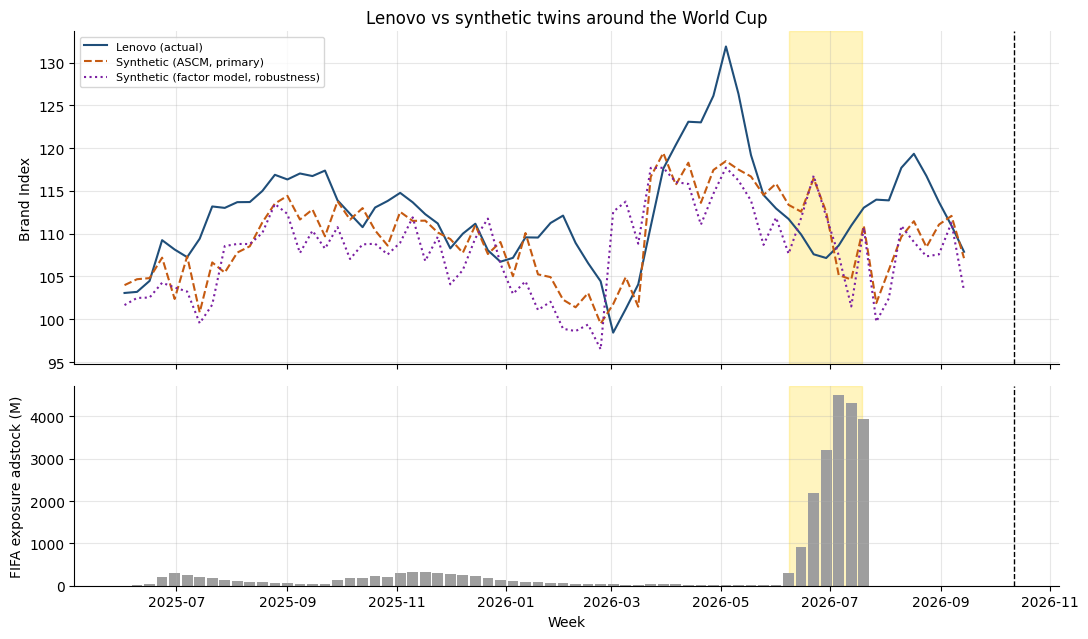

**Figure 1.** Gold band: tournament weeks (treatment week to the final). Dashed vertical line: end of the registered window (week of 12 Oct, window closes 18 Oct). Lower panel: adstocked FIFA-family Blinkfire impressions; it stops after 20 July because no later exposure has been supplied.

In [6]:
paths = pd.read_parquet(W + "weekly_paths.parquet"); paths["week"] = pd.to_datetime(paths["week"])
recent = paths[paths["week"] >= "2025-06-01"]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, gridspec_kw={"height_ratios": [2, 1.2]})
a1.plot(recent["week"], recent["actual_index"], color="#1f4e79", label="Lenovo (actual)")
a1.plot(recent["week"], recent["augmented_scm_synthetic_index"], color="#c55a11", ls="--", label="Synthetic (ASCM, primary)")
a1.plot(recent["week"], recent["generalized_scm_factor_synthetic_index"], color="#7b1fa2", ls=":", label="Synthetic (factor model, robustness)")
for a in (a1, a2):
    a.axvspan(pd.Timestamp(est["treatment_week"]), pd.Timestamp(est["final_week"]) + pd.Timedelta(days=6), color="gold", alpha=0.25)
    a.axvline(pd.Timestamp(est["window_end_week"]), color="black", ls="--", lw=1)
a1.set_ylabel("Brand Index"); a1.set_title("Lenovo vs synthetic twins around the World Cup"); a1.legend(fontsize=8)
a2.bar(recent["week"], recent["fifa_exposure_adstock"] / 1e6, width=6, color="#9e9e9e")
a2.set_ylabel("FIFA exposure adstock (M)"); a2.set_xlabel("Week")
plt.tight_layout(); plt.show()
md("**Figure 1.** Gold band: tournament weeks (treatment week to the final). Dashed vertical line: end of the registered window (week of 12 Oct, "
   "window closes 18 Oct). Lower panel: adstocked FIFA-family Blinkfire impressions; it stops after 20 July because no later exposure has been supplied.")

### 5.4 View B: placebo test

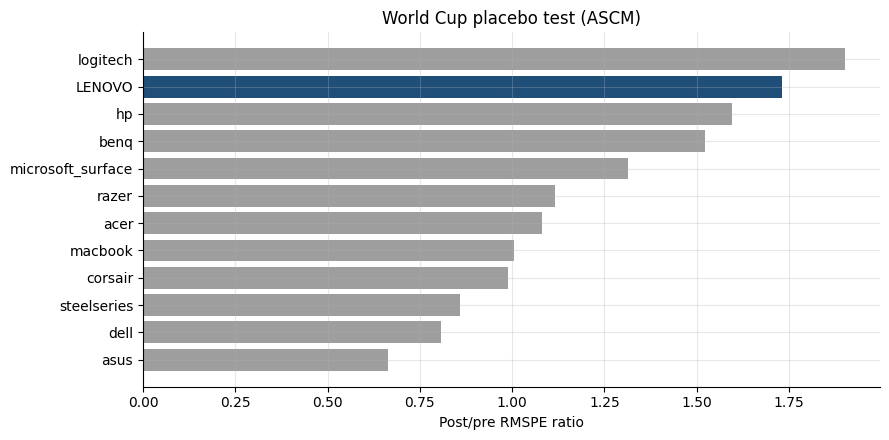

**Figure 2.** Primary p = **0.167**; p on the estimand itself = 1.000; placebo interval half-width ±8.15 points. Factor-model robustness p = 0.333 (3 factors). The tournament weeks are not unusual relative to rival brands.

In [7]:
pl = pd.read_parquet(W + "donor_placebos.parquet")
vals = pd.concat([pl[["placebo_unit", "post_pre_rmspe_ratio"]],
                  pd.DataFrame([{"placebo_unit": "LENOVO", "post_pre_rmspe_ratio": est["placebo"]["post_pre_rmspe_ratio"]}])]).sort_values("post_pre_rmspe_ratio")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(vals["placebo_unit"].str.replace("donor_", ""), vals["post_pre_rmspe_ratio"],
        color=["#1f4e79" if u == "LENOVO" else "#9e9e9e" for u in vals["placebo_unit"]])
ax.set_xlabel("Post/pre RMSPE ratio"); ax.set_title("World Cup placebo test (ASCM)")
plt.tight_layout(); plt.show()
cr = est["category_shock_robust"]["placebo"]
md(f"**Figure 2.** Primary p = **{fmt(est['placebo']['p_value'], 3)}**; p on the estimand itself = {fmt(est['placebo']['primary_estimand_p_value'], 3)}; "
   f"placebo interval half-width ±{fmt(est['placebo']['interval_half_width_index_points'])} points. "
   f"Factor-model robustness p = {fmt(cr['p_value'], 3)} ({cr['factor_count']} factors). "
   f"{'The tournament weeks are unusual relative to rival brands.' if est['placebo']['p_value'] <= 0.10 else 'The tournament weeks are not unusual relative to rival brands.'}")

### 5.5 Confounder diagnostics (never alter the estimate)

In [8]:
cd = json.loads(Path(W + "confounder_diagnostics.json").read_text())
seasonal = pd.DataFrame(cd["seasonal_same_window_prior_years"]).rename(columns={
    "window_start": "Same calendar window starting", "lenovo_minus_weighted_donors_index_points": "Lenovo minus weighted rivals (pts)"})
display(seasonal.style.format(precision=2).hide(axis="index"))
loo = pd.Series(cd["leave_one_donor_out_mean_gap"]).rename(lambda s: s.replace("donor_", "")).sort_values()
ld = cd["category_shock_loading"]
md(f"""**Table 4 and checks.**
- *Pre-trend:* mean gap in the last 8 pre-tournament weeks {fmt(cd['pre_trend']['last_8_pre_weeks_mean_gap'], signed=True)} points, slope {fmt(cd['pre_trend']['last_8_pre_weeks_slope_per_week'], signed=True)} points/week.
- *Seasonality:* the same calendar window in earlier years (table) vs {fmt(cd['current_window_same_construction_index_points'], signed=True)} this year.
- *Leave-one-donor-out* mean gap ranges {fmt(loo.min(), signed=True)} ({loo.idxmin()}) to {fmt(loo.max(), signed=True)} ({loo.idxmax()}): no single rival drives the result.
- *Category-shock loading (raw search volumes, not shares):* Lenovo moves {fmt(ld['loading'])}× the rival median year-on-year; after that adjustment the tournament residual is {fmt(ld['loading_adjusted_residual_tournament_pct'], 1, True)}% ({fmt(ld['tournament_residual_in_sd_units'], 2, True)} s.d.) and {fmt(ld['loading_adjusted_residual_after_final_pct'], 1, True)}% after the final.""")

Same calendar window starting,Lenovo minus weighted rivals (pts)
2025-06-09,4.65
2024-06-10,0.23
2023-06-12,0.98
2022-06-13,-2.22


**Table 4 and checks.**
- *Pre-trend:* mean gap in the last 8 pre-tournament weeks +5.59 points, slope -1.48 points/week.
- *Seasonality:* the same calendar window in earlier years (table) vs -2.92 this year.
- *Leave-one-donor-out* mean gap ranges +2.39 (logitech) to +4.08 (macbook): no single rival drives the result.
- *Category-shock loading (raw search volumes, not shares):* Lenovo moves 1.18× the rival median year-on-year; after that adjustment the tournament residual is -3.7% (-0.71 s.d.) and -0.3% after the final.

## 6. Interpretation

In [9]:
md(f"""- **View A (within the total effect):** during the tournament Lenovo sat {fmt(view_a.iloc[1, 4], signed=True)} points above its no-sponsorship twin
  and {fmt(view_a.iloc[2, 4], signed=True)} after the final, against {fmt(view_a.iloc[0, 4], signed=True)} earlier in the sponsorship: the tournament weeks were
  {'above' if view_a.iloc[1, 4] > view_a.iloc[0, 4] else 'below'} the earlier sponsorship average, so the World Cup
  {'stood out from' if view_a.iloc[1, 4] > view_a.iloc[0, 4] else 'did not stand out from'} the rest of the sponsorship in this view.
  The weeks after the final were {'above' if view_a.iloc[2, 4] > view_a.iloc[0, 4] else 'below'} the earlier average
  ({fmt(view_a.iloc[2, 4] - view_a.iloc[0, 4], signed=True)} points), {'consistent with' if view_a.iloc[2, 4] > view_a.iloc[0, 4] else 'not suggesting'}
  a post-tournament after-effect; with {view_a.iloc[2, 3]} weeks observed this is not yet tested.
- **View B (incremental, pre-registered):** the primary estimate is **{fmt(prim['primary_exposure_weighted_gap'], signed=True)} Brand Index points**,
  with the tournament weeks at {fmt(prim['tournament_mean_gap'], signed=True)} and the weeks after the final at {fmt(prim['post_event_persistence_mean_gap'], signed=True)}.
  {'The tournament weeks sit above' if prim['tournament_mean_gap'] > 0 else 'The tournament weeks do not sit above'} Lenovo's pre-tournament trajectory
  ({'and the gap is ' + ('larger' if (prim['post_event_persistence_mean_gap'] or 0) > prim['tournament_mean_gap'] else 'smaller') + ' after the final' if prim['post_event_persistence_mean_gap'] is not None else 'no post-final weeks yet'}).
- **Reference case:** Lenovo's own trajectory up to the tournament, which already includes the 2024–2026 sponsorship (this is the *incremental* World Cup effect, not the total sponsorship effect).
- **Uncertainty:** placebo p = {fmt(est['placebo']['p_value'], 3)}; {'few' if est['placebo']['p_value'] <= 0.10 else 'several'} rival brands show comparable movements.
  The holdout error ({fmt(prim['holdout_rmspe_index_points'])} vs in-sample {fmt(prim['pre_rmspe_index_points'])}) shows how well the comparison tracked the months before the tournament.
- **Decision relevance:** none yet for valuation. The result becomes decision-grade only when all gates pass after the window closes.""")

- **View A (within the total effect):** during the tournament Lenovo sat +7.14 points above its no-sponsorship twin
  and +12.56 after the final, against +6.97 earlier in the sponsorship: the tournament weeks were
  above the earlier sponsorship average, so the World Cup
  stood out from the rest of the sponsorship in this view.
  The weeks after the final were above the earlier average
  (+5.59 points), consistent with
  a post-tournament after-effect; with 9 weeks observed this is not yet tested.
- **View B (incremental, pre-registered):** the primary estimate is **+0.58 Brand Index points**,
  with the tournament weeks at -1.47 and the weeks after the final at +5.43.
  The tournament weeks do not sit above Lenovo's pre-tournament trajectory
  (and the gap is larger after the final).
- **Reference case:** Lenovo's own trajectory up to the tournament, which already includes the 2024–2026 sponsorship (this is the *incremental* World Cup effect, not the total sponsorship effect).
- **Uncertainty:** placebo p = 0.167; several rival brands show comparable movements.
  The holdout error (9.79 vs in-sample 3.63) shows how well the comparison tracked the months before the tournament.
- **Decision relevance:** none yet for valuation. The result becomes decision-grade only when all gates pass after the window closes.

## 7. Limitations and non-claims

- **Interim, not accepted.** Open gates (approved activation date, data coverage to 18 Oct, Blinkfire after 20 Jul, 13 persistence weeks, placebo p) mean this is a description of the data so far.
- **Incremental only.** The estimate is the World Cup's addition above a trajectory that already contains the sponsorship; it says nothing about the total value of the partnership.
- **Brand share of attention, not brand equity.** The GWI survey in the index ends at 2026Q1, so the tournament weeks rest on search share alone; rivals have no survey series.
- **Outcome amended after interim results.** See the protocol amendment above (ADR-0040).
- **Digital exposure only.** Broadcast audiences are not measured; media value does not yet cover June–July 2026.
- **Post-hoc robustness.** The factor-model specification was added after early tournament data had been seen and may never become primary.
- **Two-sided gate.** A large *negative* gap could pass the placebo test and would be handed over with its sign.
- **Unmodelled uncertainty.** Trends sampling and revision, donor contamination not found by the screen, and the provisional activation date are outside the placebo p-value.

## Next steps

1. After 18 October 2026: re-pull Google Trends (reset the pinned donor vintage), rebuild, and re-run this notebook.
2. Obtain the client's approved activation date and Blinkfire data after 20 July.
3. Before the window closes, extend the engine's donor pool selection to the 15 screened candidate brands using pre-period evidence only.